# Capítulo 9 — Boletins e Análise de Cartas: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | parser de METAR (aeroportos brasileiros) | Python puro |
| 2 | o modelo de estação oficial | `MetPy` StationPlot |
| 3 | análise objetiva de Cressman: de pontos a isóbaras | NumPy |
| 4 | redução ao nível do mar: o mapa errado × o sinótico | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap09_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

Rd, g = 287.0, 9.8

## Caso 1 — Um parser de METAR em 40 linhas

Grupo a grupo: estação, hora, vento `dddffKT`, visibilidade, tempo presente, nuvens `BKN015`, `TT/TdTd`, `Qpppp`.

In [2]:
METARS = [
    'SBGR 221800Z 12008KT 8000 -RA BKN015 OVC080 22/19 Q1016',
    'SBSP 221800Z 14012KT 9999 SCT025 BKN090 24/18 Q1015',
    'SBRJ 221800Z 18015KT 9999 FEW020 28/23 Q1012',
    'SBCT 221800Z 09006KT 6000 DZ OVC008 16/15 Q1019',
    'SBPA 221800Z 21018KT 9999 TS SCT030CB 26/21 Q1009',
    'SBBR 221800Z 10009KT 9999 FEW035 27/12 Q1014',
]

def decodifica(metar):
    m = {}
    m['estacao'], resto = metar.split(' ', 1)
    m['hora_utc'] = re.search(r'(\d{2})(\d{2})(\d{2})Z', resto).group(2, 3)
    v = re.search(r'(\d{3})(\d{2})(G\d{2})?KT', resto)
    m['dir_vento'], m['vel_kt'] = int(v.group(1)), int(v.group(2))
    vis = re.search(r' (\d{4}) ', resto)
    m['vis_m'] = int(vis.group(1)) if vis else 9999
    m['tempo'] = (re.findall(r' ([+-]?(?:RA|DZ|TS|FG|SN|SH)[A-Z]*) ', resto) or ['—'])[0]
    m['nuvens'] = re.findall(r'(FEW|SCT|BKN|OVC)(\d{3})([A-Z]{2})?', resto)
    tt = re.search(r' (\d{2})/(\d{2}) ', resto)
    m['T'], m['Td'] = int(tt.group(1)), int(tt.group(2))
    m['QNH'] = int(re.search(r'Q(\d{4})', resto).group(1))
    return m

print(f"{'estação':8s} {'vento':>10s} {'vis':>6s} {'tempo':>6s} "
      f"{'teto':>8s} {'T/Td':>7s} {'QNH':>6s} {'UR%':>4s} {'LCL m':>6s}")
dados = []
for mt in METARS:
    d = decodifica(mt)
    teto = next((f"{int(c[1])*100} ft" for c in d['nuvens']
                 if c[0] in ('BKN', 'OVC')), '—')
    es = lambda T: 0.6113*np.exp(5423*(1/273.15 - 1/(T+273.15)))
    UR = 100*es(d['Td'])/es(d['T'])
    lcl = 125*(d['T'] - d['Td'])            # Cap. 4!
    dados.append(d)
    print(f"{d['estacao']:8s} {d['dir_vento']:3d}°/{d['vel_kt']:2d}kt "
          f"{d['vis_m']:6d} {d['tempo']:>6s} {teto:>8s} "
          f"{d['T']:3d}/{d['Td']:2d} {d['QNH']:6d} {UR:4.0f} {lcl:6.0f}")

estação       vento    vis  tempo     teto    T/Td    QNH  UR%  LCL m
SBGR     120°/ 8kt   8000    -RA  1500 ft  22/19   1016   83    375
SBSP     140°/12kt   9999      —  9000 ft  24/18   1015   69    750
SBRJ     180°/15kt   9999      —        —  28/23   1012   74    625
SBCT      90°/ 6kt   6000     DZ   800 ft  16/15   1019   94    125
SBPA     210°/18kt   9999     TS        —  26/21   1009   73    625
SBBR     100°/ 9kt   9999      —        —  27/12   1014   39   1875


## Caso 2 — O modelo de estação oficial (MetPy)

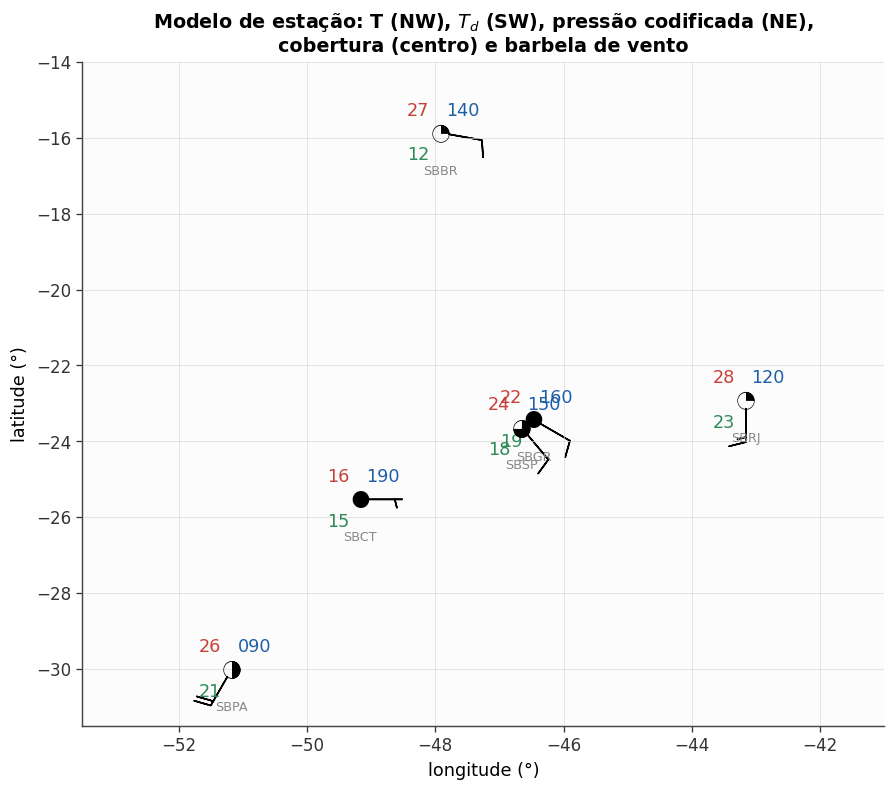

In [3]:
from metpy.plots import StationPlot, sky_cover
from metpy.units import units

# posições aproximadas (lon, lat) das estações
pos = {'SBGR': (-46.47, -23.43), 'SBSP': (-46.66, -23.63),
       'SBRJ': (-43.16, -22.91), 'SBCT': (-49.17, -25.53),
       'SBPA': (-51.17, -30.00), 'SBBR': (-47.92, -15.87)}
oktas = {'FEW': 2, 'SCT': 4, 'BKN': 6, 'OVC': 8}

lons = [pos[d['estacao']][0] for d in dados]
lats = [pos[d['estacao']][1] for d in dados]
u = [-d['vel_kt']*np.sin(np.deg2rad(d['dir_vento'])) for d in dados]
v = [-d['vel_kt']*np.cos(np.deg2rad(d['dir_vento'])) for d in dados]
cov = [max([oktas.get(c[0], 0) for c in d['nuvens']] or [0]) for d in dados]

fig, ax = plt.subplots(figsize=(9, 7.5))
sp = StationPlot(ax, lons, lats, fontsize=11, spacing=14)
sp.plot_parameter('NW', [d['T'] for d in dados], color=CORES['vermelho'])
sp.plot_parameter('SW', [d['Td'] for d in dados], color=CORES['verde'])
sp.plot_parameter('NE', [int(round((d['QNH']-1000)*10)) % 1000 for d in dados],
                  color=CORES['azul'], formatter=lambda x: f'{int(x):03d}')
sp.plot_symbol('C', cov, sky_cover)
sp.plot_barb(u, v)
for d in dados:
    x, y = pos[d['estacao']]
    ax.annotate(d['estacao'], (x, y), xytext=(0, -26),
                textcoords='offset points', ha='center', fontsize=8,
                color='#888888')
ax.set(xlim=(-53.5, -41), ylim=(-31.5, -14),
       xlabel='longitude (°)', ylabel='latitude (°)',
       title='Modelo de estação: T (NW), $T_d$ (SW), pressão codificada (NE),\n'
             'cobertura (centro) e barbela de vento')
plt.show()

## Caso 3 — Análise objetiva de Cressman: de pontos a isóbaras

Observações irregulares → grade regular, por correções sucessivas com peso $w = \max(0, (R^2-d^2)/(R^2+d^2))$. O algoritmo que, refinado, virou a assimilação de dados dos modelos (Cap. 20).

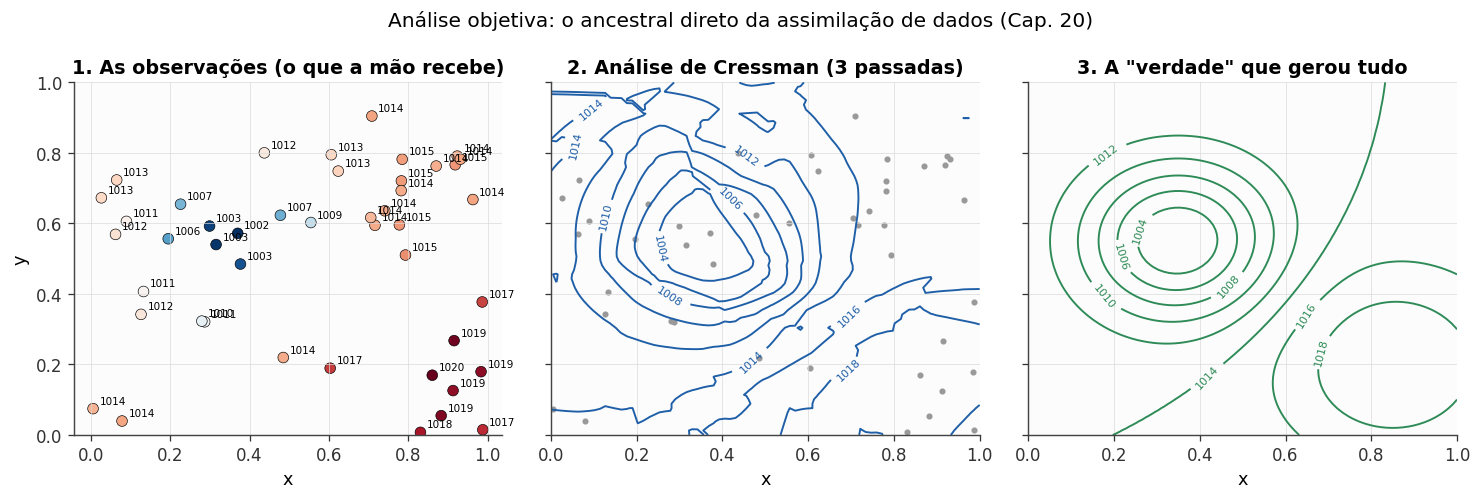

RMS análise × verdade: 0.94 hPa


In [4]:
rng = np.random.default_rng(9)

# 'verdade': baixa sinótica + cavado
def P_verdade(x, y):
    return (1014 - 12*np.exp(-((x-0.35)**2 + (y-0.55)**2)/0.05)
            + 6*np.exp(-((x-0.85)**2 + (y-0.2)**2)/0.08))

n_obs = 45
xo, yo = rng.random(n_obs), rng.random(n_obs)
Po = P_verdade(xo, yo) + rng.normal(0, 0.3, n_obs)

gx, gy = np.meshgrid(np.linspace(0, 1, 80), np.linspace(0, 1, 80))

def cressman(xo, yo, Po, raios=(0.45, 0.25, 0.12)):
    campo = np.full(gx.shape, Po.mean())
    for R in raios:                       # passadas com raio decrescente
        # interpola o campo atual nas obs (vizinho da grade)
        ii = np.clip((yo*79).astype(int), 0, 79)
        jj = np.clip((xo*79).astype(int), 0, 79)
        inc = Po - campo[ii, jj]
        num = np.zeros_like(campo); den = np.zeros_like(campo)
        for xk, yk, dk in zip(xo, yo, inc):
            d2 = (gx - xk)**2 + (gy - yk)**2
            w = np.maximum(0.0, (R**2 - d2)/(R**2 + d2))
            num += w*dk; den += w
        campo += np.where(den > 0, num/np.maximum(den, 1e-9), 0.0)
    return campo

analise = cressman(xo, yo, Po)

fig, axs = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True)
niveis = np.arange(1000, 1022, 2)
axs[0].scatter(xo, yo, c=Po, cmap='RdBu_r', s=45, edgecolor='k', lw=0.4)
for xi, yi, pi in zip(xo, yo, Po):
    axs[0].annotate(f'{pi:.0f}', (xi, yi), xytext=(4, 3),
                    textcoords='offset points', fontsize=6.5)
axs[0].set(title='1. As observações (o que a mão recebe)', xlabel='x')
cs = axs[1].contour(gx, gy, analise, levels=niveis, colors=CORES['azul'],
                    linewidths=1.2)
axs[1].clabel(cs, fmt='%d', fontsize=7)
axs[1].scatter(xo, yo, s=8, color='#999999')
axs[1].set(title='2. Análise de Cressman (3 passadas)', xlabel='x')
cs2 = axs[2].contour(gx, gy, P_verdade(gx, gy), levels=niveis,
                     colors=CORES['verde'], linewidths=1.2)
axs[2].clabel(cs2, fmt='%d', fontsize=7)
axs[2].set(title='3. A "verdade" que gerou tudo', xlabel='x')
axs[0].set_ylabel('y')
fig.suptitle('Análise objetiva: o ancestral direto da assimilação de dados (Cap. 20)')
fig.tight_layout(); plt.show()
print(f'RMS análise × verdade: '
      f'{np.sqrt(np.mean((analise - P_verdade(gx, gy))**2)):.2f} hPa')

## Caso 4 — Redução ao nível do mar: sem ela, o mapa mede montanhas

$$P_{nm} = P_{est}\exp\!\left(\frac{g\,z_{est}}{R_d\,\bar T_v}\right)$$

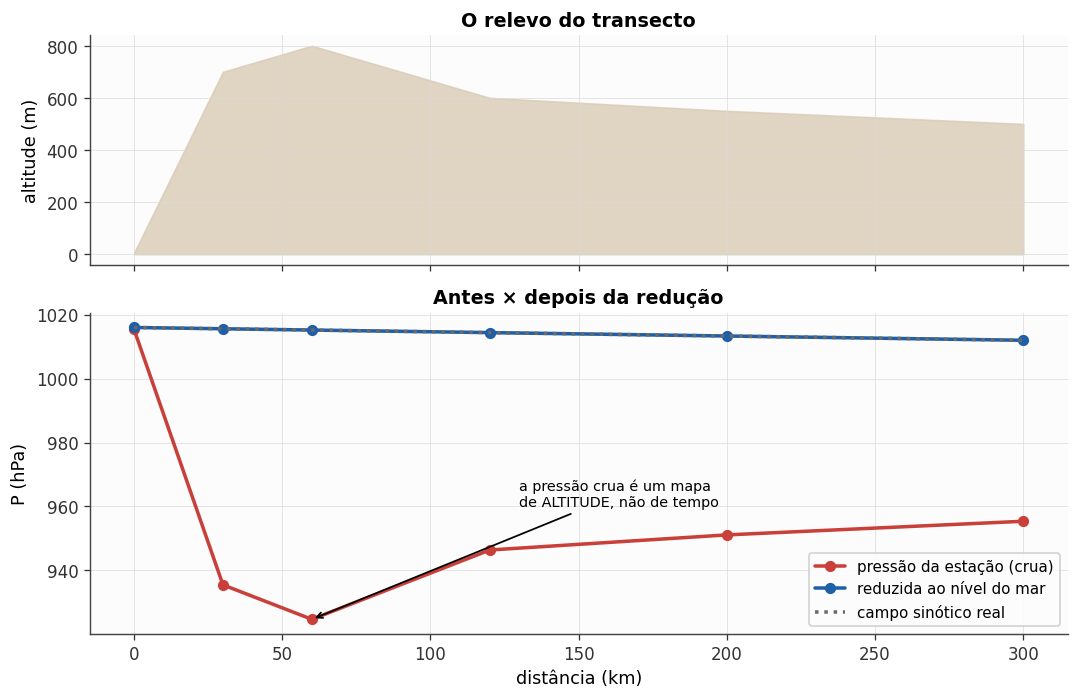

variação da pressão crua no transecto: 91 hPa (dominada pelo relevo)
variação da reduzida: 4.0 hPa (o sinal sinótico de 4 hPa) ✓


In [5]:
# transecto litoral → planalto (estilo Santos → São Paulo → interior)
nomes = ['litoral', 'serra', 'capital', 'interior1', 'interior2', 'interior3']
x_km  = np.array([0, 30, 60, 120, 200, 300])
z_est = np.array([5.0, 700.0, 800.0, 600.0, 550.0, 500.0])
T_est = np.array([26.0, 20.0, 22.0, 24.0, 25.0, 25.0]) + 273.15

# situação sinótica real: gradiente suave de 4 hPa no transecto
P_nm_real = 1016.0 - 4.0*x_km/300.0
P_est = P_nm_real*np.exp(-g*z_est/(Rd*(T_est - 0.0033*z_est)))
P_reduzida = P_est*np.exp(g*z_est/(Rd*(T_est - 0.0033*z_est)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 6.2), sharex=True,
                               height_ratios=[1, 1.4])
ax1.fill_between(x_km, z_est, color='#d9cbb5', alpha=0.8)
ax1.set(ylabel='altitude (m)', title='O relevo do transecto')
ax2.plot(x_km, P_est, 'o-', color=CORES['vermelho'],
         label='pressão da estação (crua)')
ax2.plot(x_km, P_reduzida, 'o-', color=CORES['azul'],
         label='reduzida ao nível do mar')
ax2.plot(x_km, P_nm_real, ':', color=CORES['cinza'], label='campo sinótico real')
ax2.annotate('a pressão crua é um mapa\nde ALTITUDE, não de tempo',
             xy=(60, P_est[2]), xytext=(130, 960), fontsize=9,
             arrowprops=dict(arrowstyle='->', lw=1.1))
ax2.set(xlabel='distância (km)', ylabel='P (hPa)',
        title='Antes × depois da redução')
ax2.legend()
fig.tight_layout(); plt.show()
print('variação da pressão crua no transecto: '
      f'{P_est.max()-P_est.min():.0f} hPa (dominada pelo relevo)')
print('variação da reduzida: '
      f'{P_reduzida.max()-P_reduzida.min():.1f} hPa (o sinal sinótico de 4 hPa) ✓')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap09_solucoes.ipynb`**.

**N1** — Estenda o parser: rajadas (`14012G25KT`), vento variável (`VRB03KT`), `CAVOK` e METARs sem grupo de tempo; teste com os dois boletins extras: `SBFL 221800Z VRB03KT CAVOK 25/20 Q1013` e `SBSV 221800Z 09015G27KT 9999 SCT020 30/24 Q1010`.

**N2** — Acrescente as duas estações do N1 ao mapa do Caso 2.

**N3** — Validação cruzada no Cressman: reserve 10 observações, varra o raio da última passada de 0,05 a 0,4 e trace o RMS nas reservadas; ache o raio ótimo.

**N4** — Numa manhã de inversão (ar da estação 8 K mais frio que a média da coluna), quantifique o erro da redução ao nível do mar para a estação de 800 m — e explique as "altas frias" fantasmas de inverno no planalto.

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*